# Loading Libraries and Packages

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pandas as pd
import cv2
import pandas as pd
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Phase 1: Tree Ensembles & Boosting (Air Quality Data)

## Data Loading and pre-processing (for 1.1-1.3)

In [10]:
# Load data
df = pd.read_csv('../Data/delhi_aqi.csv')

# Convert target → binary classification
df['pm2_5'] = (df['pm2_5'] > 200).astype(int)

# Parse datetime
df['date'] = pd.to_datetime(df['date'])

# Extract temporal features
df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.dayofyear
df['month'] = df['date'].dt.month

# Cyclic encoding
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['day_sin'] = np.sin(2 * np.pi * df['day'] / 365.25)
df['day_cos'] = np.cos(2 * np.pi * df['day'] / 365.25)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Drop unused columns
df = df.drop(columns=['date', 'hour', 'day', 'month'])

## TRAIN-VAL-TEST SPLIT
n = len(df)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

## 1.1 Information Gain from Scratch

In [11]:
def gini_impurity(y):
    if len(y) == 0:
        return 0.0
    
    p = np.mean(y)   # probability of class 1
    return 1 - (p**2 + (1 - p)**2)

def compute_best_threshold(df, feature, target):
    data = df[[feature, target]].dropna()
    
    X = data[feature].values
    y = data[target].values
    
    n = len(y)
    if n == 0:
        return None, 0.0
    
    # Parent impurity
    parent_gini = gini_impurity(y)
    
    # Sort feature values
    order = np.argsort(X)
    X_sorted = X[order]
    y_sorted = y[order]
    
    # Candidate thresholds = midpoints of unique values
    unique_vals = np.unique(X_sorted)
    thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2.0
    
    best_gain = -1
    best_threshold = None
    
    for t in thresholds:
        left_mask = X_sorted <= t
        right_mask = ~left_mask
        
        y_left = y_sorted[left_mask]
        y_right = y_sorted[right_mask]
        
        if len(y_left) == 0 or len(y_right) == 0:
            continue
        
        # Compute child impurities
        g_left = gini_impurity(y_left)
        g_right = gini_impurity(y_right)
        
        # Weighted impurity
        w_left = len(y_left) / n
        w_right = len(y_right) / n
        
        split_gini = w_left * g_left + w_right * g_right
        
        # Gini reduction (gain)
        gain = parent_gini - split_gini
        
        if gain > best_gain:
            best_gain = gain
            best_threshold = t
    
    return best_threshold, best_gain

In [26]:
feature_name = 'co'   # replacing Temperature
target_name = 'pm2_5'

threshold, gain = compute_best_threshold(train_df, feature_name, target_name)

print(f"No Temperature feature available. Using column: {feature_name} instead.")
print("#"*15,"Statistics of the feature column","#"*15)
print(train_df[feature_name].describe(),'\n')
print(f"Feature: {feature_name}")
print(f"Optimal Threshold: {threshold:.6f}")
print(f"Gini Impurity Reduction: {gain:.6f}")

No Temperature feature available. Using column: co instead.
############### Statistics of the feature column ###############
count    13143.000000
mean      2992.605783
std       2885.219741
min        270.370000
25%       1081.470000
50%       1869.200000
75%       3791.810000
max      21148.680000
Name: co, dtype: float64 

Feature: co
Optimal Threshold: 2790.450000
Gini Impurity Reduction: 0.282794


## 1.2 Random Forest

In [30]:
import numpy as np
from collections import Counter

class Node:
    """A node in the decision tree."""
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        
    def is_leaf_node(self):
        return self.value is not None

class DecisionTree:
    """A depth-limited decision tree with feature bagging."""
    def __init__(self, max_depth=10, max_features=None):
        self.max_depth = max_depth
        self.max_features = max_features
        self.root = None

    def fit(self, X, y):
        # Default to sqrt(n_features) if max_features is not specified
        self.n_features_ = X.shape[1]
        if self.max_features is None:
            self.max_features = int(np.sqrt(self.n_features_))
            
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_feats = X.shape
        n_labels = len(np.unique(y))

        # Check stopping criteria (Depth limit, pure node, or no features left)
        if (depth >= self.max_depth or n_labels == 1 or n_samples < 2):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # Feature bagging: Randomly select a subspace of features
        feat_idxs = np.random.choice(n_feats, self.max_features, replace=False)

        # Find the best split among the random subset of features
        best_feat, best_thresh = self._best_split(X, y, feat_idxs)

        # If no valid split is found, create a leaf
        if best_feat is None:
            return Node(value=self._most_common_label(y))

        # Split the data
        left_idxs, right_idxs = self._split(X[:, best_feat], best_thresh)
        
        # Grow children
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)
        
        return Node(best_feat, best_thresh, left, right)

    def _best_split(self, X, y, feat_idxs):
        best_gain = -1
        split_idx, split_thresh = None, None
        
        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            
            for thresh in thresholds:
                gain = self._gini_gain(y, X_column, thresh)
                
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_thresh = thresh
                    
        return split_idx, split_thresh

    def _gini_gain(self, y, X_column, split_thresh):
        parent_gini = self._calculate_gini(y)
        
        left_idxs, right_idxs = self._split(X_column, split_thresh)
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0
            
        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        e_l, e_r = self._calculate_gini(y[left_idxs]), self._calculate_gini(y[right_idxs])
        
        child_gini = (n_l / n) * e_l + (n_r / n) * e_r
        return parent_gini - child_gini

    def _calculate_gini(self, y):
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return 1.0 - np.sum(probabilities**2)

    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs

    def _most_common_label(self, y):
        counter = Counter(y)
        return counter.most_common(1)[0][0]

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value
        
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)


class RandomForest:
    """An ensemble of depth-limited trees with feature bagging."""
    def __init__(self, n_trees=10, max_depth=10, max_features=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.max_features = max_features
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        for _ in range(self.n_trees):
            # Bootstrapping: Random sampling of rows with replacement
            X_sample, y_sample = self._bootstrap_samples(X, y)
            
            # Initialize and train a single decision tree
            tree = DecisionTree(max_depth=self.max_depth, max_features=self.max_features)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def _bootstrap_samples(self, X, y):
        n_samples = X.shape[0]
        idxs = np.random.choice(n_samples, n_samples, replace=True)
        return X[idxs], y[idxs]

    def predict(self, X):
        # Collect predictions from all trees in the ensemble
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        
        # tree_preds is shape (n_trees, n_samples). Swap axes to (n_samples, n_trees)
        tree_preds = np.swapaxes(tree_preds, 0, 1)
        
        # Majority voting
        predictions = np.array([self._most_common_label(pred) for pred in tree_preds])
        return predictions
        
    def _most_common_label(self, y):
        counter = Counter(y)
        return counter.most_common(1)[0][0]

In [40]:
# Extract target labels separately
y_train = X_train_df['pm2_5'].to_numpy()
y_test = X_test_df['pm2_5'].to_numpy()

# (Optional) Remove target column from feature matrices if not already removed
# This ensures no leakage (safe practice)
feature_cols = [col for col in X_train_df.columns if col != 'pm2_5']

X_train_np = X_train_df[feature_cols].values
X_test_np = X_test_df[feature_cols].values

# Apply scaling already computed earlier
scaler = StandardScaler()
X_train_np = scaler.fit_transform(X_train_df[feature_cols])
X_test_np = scaler.transform(X_test_df[feature_cols])

# Initialize ensemble
rf_model = RandomForest(
    n_trees=15,
    max_depth=5,
    max_features=int(np.sqrt(X_train_np.shape[1]))  # explicit feature bagging
)

print("Training Model...")
# Train
rf_model.fit(X_train_np, y_train)

print()
print("Testing Model...")
# Inference
y_pred = rf_model.predict(X_test_np)

# Accuracy computation (rewritten)
correct = (y_pred == y_test).sum()
total = y_test.shape[0]
acc = correct / total

print(f"Test Accuracy (Random Forest): {acc*100:.4f}%")

Training Model...

Testing Model...
Test Accuracy (Random Forest): 97.2656%


## 1.3 AdaBoost Sample Reweighting

In [42]:
### Stumps ###
class WeakStump:
    """
    Single-level decision rule: splits on one feature using a threshold.
    """
    def __init__(self):
        self.split_feature = None
        self.split_value = None
        self.direction = 1
        self.weight = None  # alpha

    def forward(self, X):
        n = X.shape[0]
        col = X[:, self.split_feature]

        preds = np.ones(n)

        if self.direction == 1:
            preds[col < self.split_value] = -1
        else:
            preds[col >= self.split_value] = -1

        return preds

In [43]:
#### ADA BOOST ###
def run_adaboost_with_tracking(X, y, T=50):
    """
    AdaBoost.M1 implementation with tracking of weight evolution.
    """
    n_samples, n_features = X.shape

    # Convert labels → {-1, +1}
    y_mod = np.where(y > 0, 1, -1)

    # Initialize uniform distribution
    sample_w = np.full(n_samples, 1.0 / n_samples)

    # Tracking structures
    weight_log = np.zeros((n_samples, T))
    error_freq = np.zeros(n_samples)

    for t in range(T):
        best_stump = WeakStump()
        best_err = np.inf

        # Search best split
        for j in range(n_features):
            feature_vals = X[:, j]

            # Reduced candidate thresholds (efficiency)
            cand_thresholds = np.percentile(feature_vals, np.linspace(0, 100, 20))

            for thr in cand_thresholds:
                pred = np.ones(n_samples)
                pred[feature_vals < thr] = -1

                err = np.sum(sample_w[y_mod != pred])

                polarity = 1
                if err > 0.5:
                    err = 1 - err
                    polarity = -1

                if err < best_err:
                    best_err = err
                    best_stump.split_feature = j
                    best_stump.split_value = thr
                    best_stump.direction = polarity

        # Numerical stability
        best_err = np.clip(best_err, 1e-12, 1 - 1e-12)

        # Compute alpha
        alpha = 0.5 * np.log((1 - best_err) / best_err)
        best_stump.weight = alpha

        # Predictions
        stump_pred = best_stump.forward(X)

        # Track misclassification
        mis_idx = (y_mod != stump_pred)
        error_freq += mis_idx

        # Weight update rule
        sample_w *= np.exp(-alpha * y_mod * stump_pred)

        # Normalize
        sample_w /= np.sum(sample_w)

        # Store trajectory
        weight_log[:, t] = sample_w

        print(f"[Round {t+1}] error={best_err:.4f}, alpha={alpha:.4f}")

    return weight_log, error_freq

In [55]:
def plot_top_weights(weight_log, error_freq, T, save_path = None):
    # Identify hardest samples
    hardest = np.argsort(error_freq)[-5:][::-1]

    plt.figure(figsize=(10, 6))

    for idx in hardest:
        plt.plot(
            np.arange(1, T+1),
            weight_log[idx],
            marker='o',
            markersize=3,
            label=f'Idx {idx} | errors={int(error_freq[idx])}'
        )

    plt.yscale('log')
    plt.xlabel("Boosting Iteration")
    plt.ylabel("Sample Weight (log scale)")
    plt.title("Weight Trajectory of Most Misclassified Samples")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path,dpi = 300)
    plt.show()

In [58]:
# Target extraction
y_train = X_train_df['pm2_5'].to_numpy()
y_test = X_test_df['pm2_5'].to_numpy()

# Drop target from feature set
train_features = X_train_df.drop(columns=['pm2_5'])
test_features = X_test_df.drop(columns=['pm2_5'])

X_train_np = train_features.to_numpy()
X_test_np = test_features.to_numpy()

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_np)
X_test_scaled = scaler.transform(X_test_np)

T = 50

weights_hist, misclass_stats = run_adaboost_with_tracking(X_train_scaled,y_train,T=T)

[Round 1] error=0.0461, alpha=1.5148
[Round 2] error=0.1862, alpha=0.7375
[Round 3] error=0.2270, alpha=0.6127
[Round 4] error=0.2857, alpha=0.4581
[Round 5] error=0.3241, alpha=0.3674
[Round 6] error=0.3321, alpha=0.3494
[Round 7] error=0.3206, alpha=0.3756
[Round 8] error=0.3411, alpha=0.3293
[Round 9] error=0.3241, alpha=0.3675
[Round 10] error=0.3741, alpha=0.2574
[Round 11] error=0.3538, alpha=0.3012
[Round 12] error=0.3380, alpha=0.3361
[Round 13] error=0.3556, alpha=0.2972
[Round 14] error=0.4022, alpha=0.1982
[Round 15] error=0.4175, alpha=0.1665
[Round 16] error=0.3967, alpha=0.2096
[Round 17] error=0.3909, alpha=0.2217
[Round 18] error=0.3876, alpha=0.2286
[Round 19] error=0.3921, alpha=0.2192
[Round 20] error=0.4105, alpha=0.1810
[Round 21] error=0.4166, alpha=0.1684
[Round 22] error=0.4106, alpha=0.1807
[Round 23] error=0.4208, alpha=0.1598
[Round 24] error=0.4236, alpha=0.1540
[Round 25] error=0.4183, alpha=0.1648
[Round 26] error=0.4146, alpha=0.1725
[Round 27] error=0.43

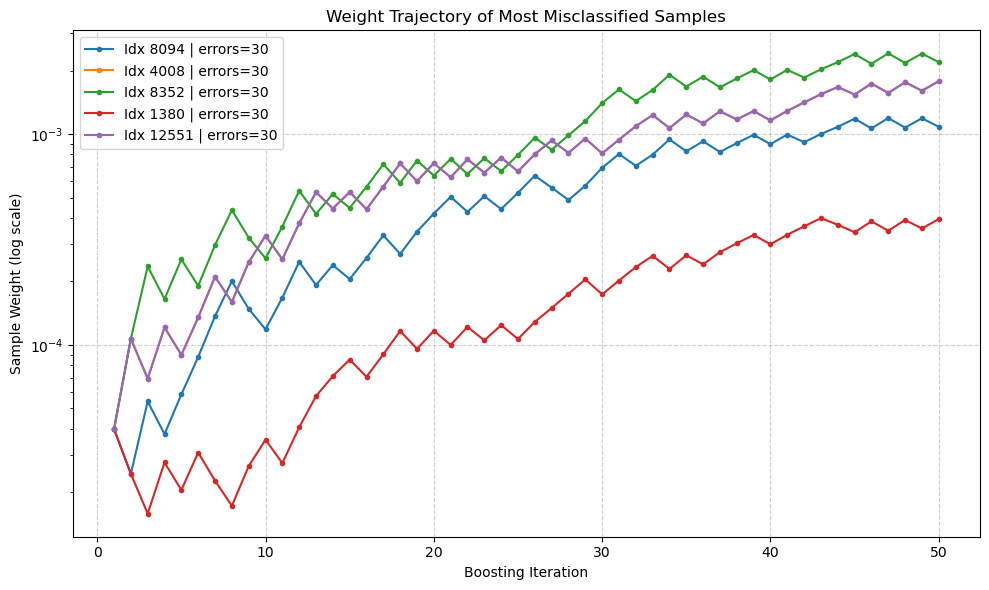

In [59]:
# Plot results
img_save_path = "../Report/1_3.png"
plot_top_weights(weights_hist, misclass_stats, T, img_save_path)

## 1.4 Gradient Boosting Residuals (Regression):

In [65]:
###### Loading and Preprocessing ######

df = pd.read_csv('../Data/delhi_aqi.csv')

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Extract temporal components
df['hr'] = df['date'].dt.hour
df['dy'] = df['date'].dt.dayofyear
df['mn'] = df['date'].dt.month

# Cyclic transformations
df['hr_sin'] = np.sin(2 * np.pi * df['hr'] / 24)
df['hr_cos'] = np.cos(2 * np.pi * df['hr'] / 24)

df['dy_sin'] = np.sin(2 * np.pi * df['dy'] / 365.25)
df['dy_cos'] = np.cos(2 * np.pi * df['dy'] / 365.25)

df['mn_sin'] = np.sin(2 * np.pi * df['mn'] / 12)
df['mn_cos'] = np.cos(2 * np.pi * df['mn'] / 12)

# Drop raw time columns
df = df.drop(columns=['date', 'hr', 'dy', 'mn'])

N = len(df)

train_end = int(0.7 * N)
val_end = int(0.85 * N)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

# Continuous target
y_train = train_df['pm2_5'].values

# Remove target from inputs
X_train_df = train_df.drop(columns=['pm2_5'])
X_val_df = val_df.drop(columns=['pm2_5'])
X_test_df = test_df.drop(columns=['pm2_5'])

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_df.values)
X_val = scaler.transform(X_val_df.values)
X_test = scaler.transform(X_test_df.values)

In [62]:
###### Gradient Boosting ######

class RegNode:
    def __init__(self, feat=None, thresh=None, left=None, right=None, val=None):
        self.feat = feat
        self.thresh = thresh
        self.left = left
        self.right = right
        self.val = val


class SimpleRegTree:
    def __init__(self, depth_limit=3):
        self.depth_limit = depth_limit
        self.root = None

    def fit(self, X, y):
        self.root = self._build(X, y, level=0)

    def _build(self, X, y, level):
        if level >= self.depth_limit or len(y) < 2:
            return RegNode(val=np.mean(y))

        best_f, best_t = self._find_split(X, y)

        if best_f is None:
            return RegNode(val=np.mean(y))

        mask = X[:, best_f] <= best_t

        left = self._build(X[mask], y[mask], level + 1)
        right = self._build(X[~mask], y[~mask], level + 1)

        return RegNode(best_f, best_t, left, right)

    def _find_split(self, X, y):
        best_score = float('inf')
        best_feat, best_thresh = None, None

        for j in range(X.shape[1]):
            candidates = np.percentile(X[:, j], [25, 50, 75])

            for t in candidates:
                left = X[:, j] <= t
                right = ~left

                if left.sum() == 0 or right.sum() == 0:
                    continue

                loss = (np.var(y[left]) * left.sum() +
                        np.var(y[right]) * right.sum())

                if loss < best_score:
                    best_score = loss
                    best_feat = j
                    best_thresh = t

        return best_feat, best_thresh

    def predict(self, X):
        return np.array([self._infer(x, self.root) for x in X])

    def _infer(self, x, node):
        if node.val is not None:
            return node.val

        if x[node.feat] <= node.thresh:
            return self._infer(x, node.left)
        return self._infer(x, node.right)

In [63]:
###### Gradient Boosting (Variance) ######

def gradient_boosting_variance(X, y, checkpoints=[1,5,10,50], lr=0.1, depth=3):
    
    n = len(y)
    
    # Initial prediction (mean)
    pred = np.full(n, np.mean(y))
    
    results = []
    max_iter = max(checkpoints)

    for i in range(1, max_iter + 1):
        # Residuals
        resid = y - pred
        
        # Fit weak learner
        tree = SimpleRegTree(depth_limit=depth)
        tree.fit(X, resid)
        
        # Predict residuals
        update = tree.predict(X)
        
        # Update ensemble
        pred += lr * update
        
        if i in checkpoints:
            current_resid = y - pred
            var = np.var(current_resid)
            results.append(var)
            print(f"Iteration {i:2d} | Residual Variance: {var:.5f}")
    
    return results

In [71]:
###### Driver Code ######
stages = [1, 5, 10, 50]
variances = gradient_boosting_variance(X_train, y_train, checkpoints=stages, lr=0.1, depth=3)

Iteration  1 | Residual Variance: 44324.06385
Iteration  5 | Residual Variance: 20443.30317
Iteration 10 | Residual Variance: 8402.95928
Iteration 50 | Residual Variance: 991.43596


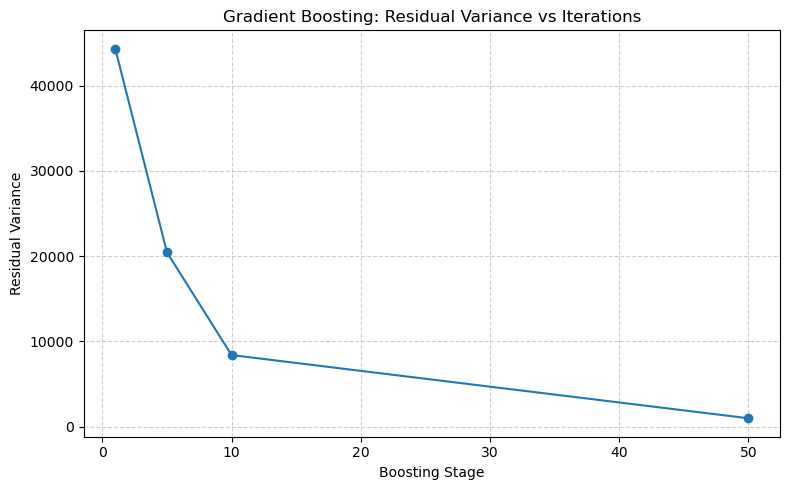

In [72]:
###### Visualization ######
img_save_path = "../Report/1_4.png"

plt.figure(figsize=(8,5))
plt.plot(stages, variances, marker='o')
plt.xlabel("Boosting Stage")
plt.ylabel("Residual Variance")
plt.title("Gradient Boosting: Residual Variance vs Iterations")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

if img_save_path:
    plt.savefig(img_save_path,dpi = 300)
    
plt.show()